In [1]:
# Airport Waiting Time Predictor


# --- Uvod i opis projekta ---
# Cilj: Predikcija prosečnog vremena čekanja na aerodromima (pasoška / bezbednosna kontrola) pomoću mašinskog učenja.
# Dataset: U.S. Airport Wait Times (6M zapisa). Sadrži atribute: aerodrom, datum/vreme, vrstu kontrole, broj putnika itd.
# Projekat obuhvata kompletan ML lifecycle: pretprocesiranje → treniranje → evaluacija → serving.

import os
import sys

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.append(project_root)


=== UČITAVANJE I OSNOVNA ANALIZA PODATAKA ===
Shape: (193921, 31)


,AirportCode,AirportName,Average_0_15_PassengerCount,Average_121_PassengerCount,Average_16_30_PassengerCount,Average_31_45_PassengerCount,Average_46_60_PassengerCount,Average_61_90_PassengerCount,Average_91_120_PassengerCount,AverageWait,...,SiteId,TerminalName,TotalPassengerCount,UsaPassengerAverageWait,UsaPassengerCount,UsaPassengerMaxWait,day_of_week,month,year,season
0,ATL,Atlanta Hartsfield-Jackson Intl Airport,200,0,0,0,0,0,0,1,...,A171,Concourse E,206,1,166,9,5,9,2022,Fall
1,ATL,Atlanta Hartsfield-Jackson Intl Airport,1123,0,232,25,0,0,0,8,...,A171,Concourse E,1415,8,1157,38,5,9,2022,Fall
2,ATL,Atlanta Hartsfield-Jackson Intl Airport,990,0,45,0,0,0,0,5,...,A171,Concourse E,1065,4,910,23,5,9,2022,Fall
3,ATL,Atlanta Hartsfield-Jackson Intl Airport,665,0,304,171,56,0,0,16,...,A171,Concourse E,1226,16,990,53,5,9,2022,Fall
4,ATL,Atlanta Hartsfield-Jackson Intl Airport,370,0,98,110,8,0,0,15,...,A171,Concourse E,599,15,401,46,5,9,2022,Fall


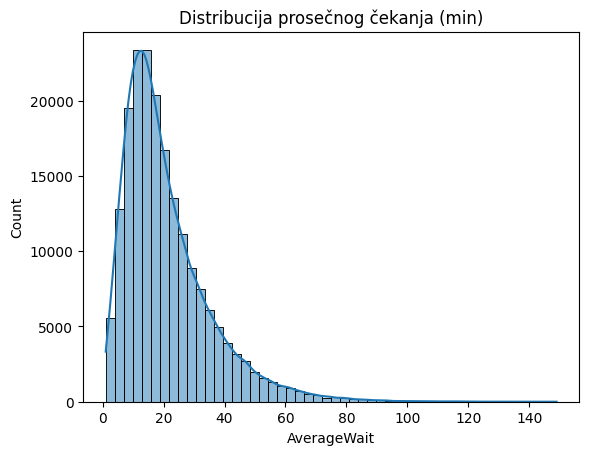

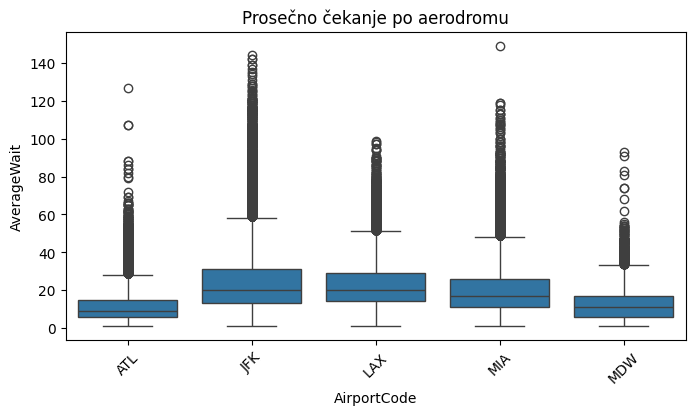

In [2]:
# --- Učitavanje podataka i osnovna analiza ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


print("\n=== UČITAVANJE I OSNOVNA ANALIZA PODATAKA ===")


df = pd.read_csv("../data/cleaned_airport_waits.csv")
print("Shape:", df.shape)
display(df.head())


# Kratak prikaz distribucije vremena čekanja
sns.histplot(df["AverageWait"], bins=50, kde=True)
plt.title("Distribucija prosečnog čekanja (min)")
plt.show()


# Boxplot prosečnog čekanja po aerodromu
plt.figure(figsize=(8, 4))
sns.boxplot(x="AirportCode", y="AverageWait", data=df)
plt.title("Prosečno čekanje po aerodromu")
plt.xticks(rotation=45)
plt.show()

In [3]:
# --- Pretprocesiranje i dodavanje novih atributa ---
from src.preprocessing import clean_data, add_date_features


print("\n=== PRETPROCESIRANJE I DODAVANJE ATRIBUTA ===")

# Dataset je već očišćen i sadrži dodatne atribute poput day_of_week i season
display(df[["day_of_week", "month", "year", "season"]].head())


=== PRETPROCESIRANJE I DODAVANJE ATRIBUTA ===


,day_of_week,month,year,season
0,5,9,2022,Fall
1,5,9,2022,Fall
2,5,9,2022,Fall
3,5,9,2022,Fall
4,5,9,2022,Fall



=== TRENIRANJE MODELA ===
=== REGRESSION PHASE ===
Train: 1400, Val: 300, Test: 300
Training Linear Regression...
Training Random Forest...
Training XGBoost...
Training MLP Regressor...


c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(



Linear Regression performance:
Validation metrics: {'MAE': 1.7645248934093343, 'RMSE': np.float64(2.906034606669964), 'R2': 0.9546198881002167}
Test metrics: {'MAE': 1.747624522617485, 'RMSE': np.float64(2.656468423862632), 'R2': 0.9721216779315893}

Random Forest performance:
Validation metrics: {'MAE': 1.6774125840154155, 'RMSE': np.float64(3.2135785291375516), 'R2': 0.9445065362678643}
Test metrics: {'MAE': 1.648201327697231, 'RMSE': np.float64(2.8381863992858407), 'R2': 0.968177144696923}

XGBoost performance:
Validation metrics: {'MAE': 1.1160467863082886, 'RMSE': np.float64(2.4160967406931753), 'R2': 0.9686315655708313}
Test metrics: {'MAE': 1.1301159858703613, 'RMSE': np.float64(1.8243515979171547), 'R2': 0.9868515729904175}

MLP Regressor performance:
Validation metrics: {'MAE': 1.7620194553341446, 'RMSE': np.float64(3.402528422737418), 'R2': 0.9377889513106625}
Test metrics: {'MAE': 1.5863025153085164, 'RMSE': np.float64(2.979424483994844), 'R2': 0.9649311051677284}

Starting

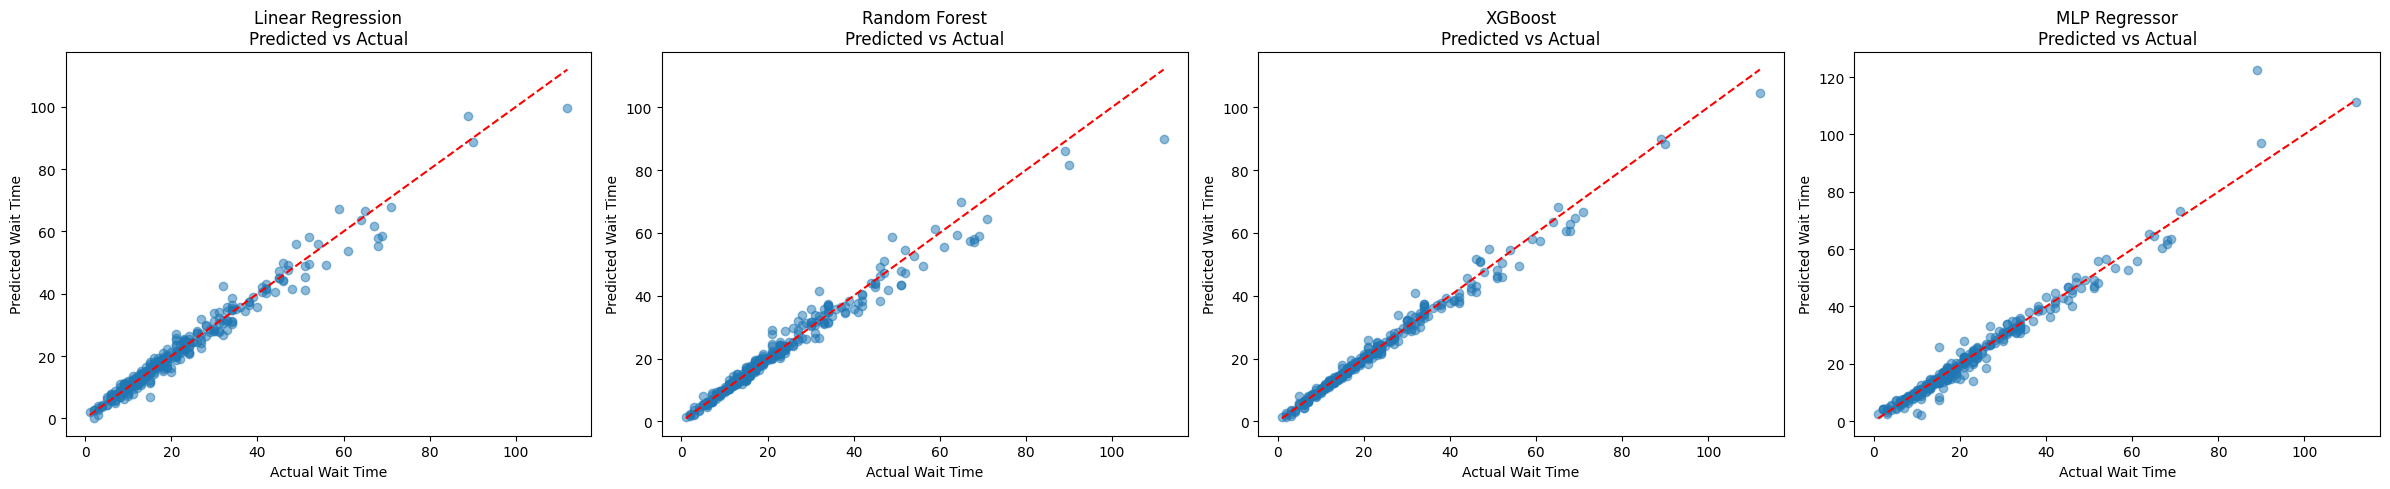

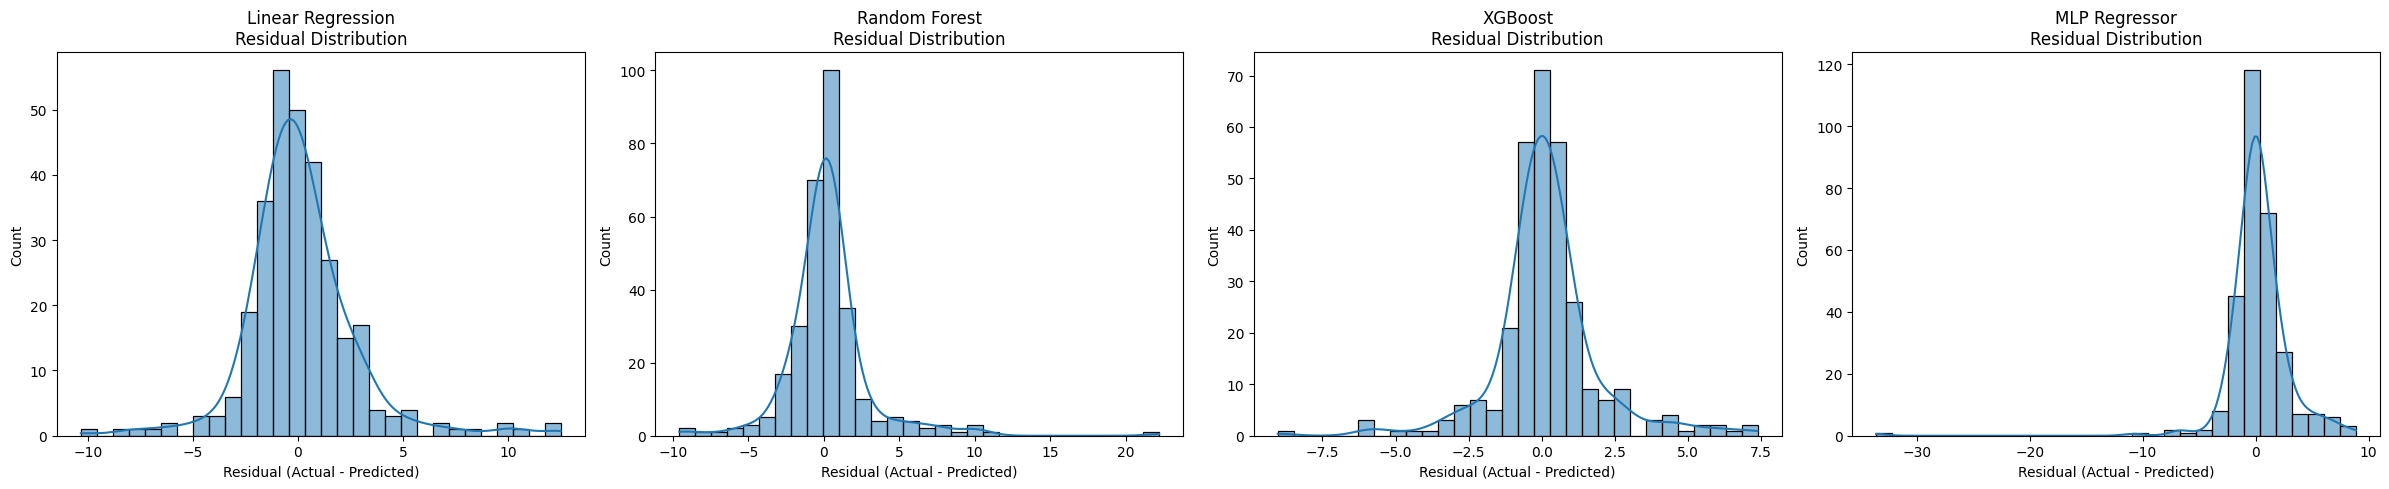

c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


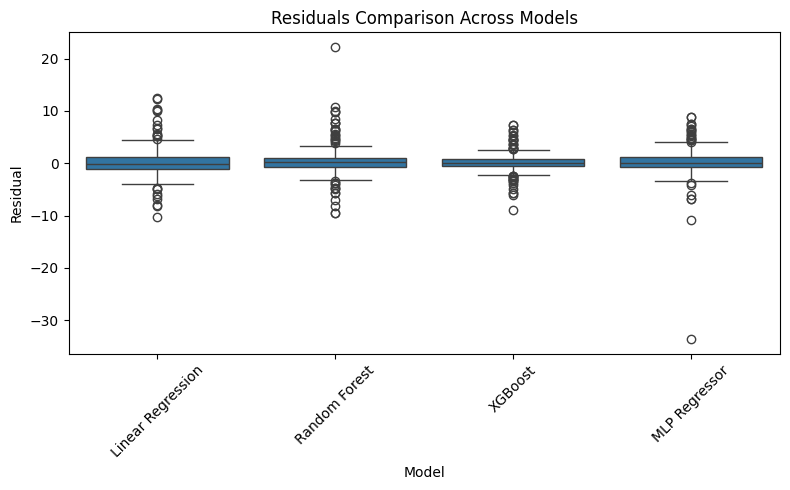


Regression phase completed successfully.

Rezultati regresionih modela:
{'Linear Regression': {'validation': {'MAE': 1.7645248934093343, 'RMSE': np.float64(2.906034606669964), 'R2': 0.9546198881002167}, 'test': {'MAE': 1.747624522617485, 'RMSE': np.float64(2.656468423862632), 'R2': 0.9721216779315893}, 'cross_val': {'MAE': {'mean': -1.5979875957911749, 'std': 0.04155653268254267, 'all_scores': [-1.6341975643895827, -1.6026705410972228, -1.6017347713508707, -1.6317533118276766, -1.519581790290522]}, 'RMSE': {'mean': -2.509495415031955, 'std': 0.17997628799315693, 'all_scores': [-2.559297710475587, -2.4477185647842368, -2.758649012809827, -2.571814998957637, -2.2099967881324862]}, 'R2': {'mean': 0.9680155376199465, 'std': 0.005177498093908801, 'all_scores': [0.9698746163088103, 0.9657858440361032, 0.9661142582896596, 0.9614246124437502, 0.9768783570214086]}}}, 'Random Forest': {'validation': {'MAE': 1.6774125840154155, 'RMSE': np.float64(3.2135785291375516), 'R2': 0.9445065362678643}, '

c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest Classifier...
Training MLP Classifier...

Logistic Regression (Classifier) performance:
Validation metrics: {'Accuracy': 0.9733333333333334, 'Precision': 0.9735316687219753, 'Recall': 0.9733333333333334, 'F1-score': 0.9732418211743724}
Test metrics: {'Accuracy': 0.96, 'Precision': 0.9604997808363286, 'Recall': 0.96, 'F1-score': 0.9600679349626534}

Random Forest (Classifier) performance:
Validation metrics: {'Accuracy': 0.92, 'Precision': 0.9198505558593039, 'Recall': 0.92, 'F1-score': 0.9199060066550032}
Test metrics: {'Accuracy': 0.9266666666666666, 'Precision': 0.9264023191823899, 'Recall': 0.9266666666666666, 'F1-score': 0.9264814678539015}

MLP Classifier performance:
Validation metrics: {'Accuracy': 0.96, 'Precision': 0.9605153874675565, 'Recall': 0.96, 'F1-score': 0.9600800521945843}
Test metrics: {'Accuracy': 0.95, 'Precision': 0.95065485495918, 'Recall': 0.95, 'F1-score': 0.9496581749213329}

Classification phase completed successfully.

Treniranje klasi

c:\Users\KORISNIK\Desktop\Fakultet\Treca godina\Racunarska inteligencija\Projekat\AirportWaitingTimePredictor\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
# --- Treniranje regresionih i klasifikacionih modela ---
from src.train_regression import train_regression
from src.train_classification import train_classification


print("\n=== TRENIRANJE MODELA ===")


# Regresija
reg_results, rf_params, xgb_params = train_regression(demo=True)
print("\nRezultati regresionih modela:")
print(reg_results)


# Klasifikacija
train_classification(demo=True)
print("\nTreniranje klasifikacionih modela završeno.")


=== VIZUALIZACIJA REZULTATA ===


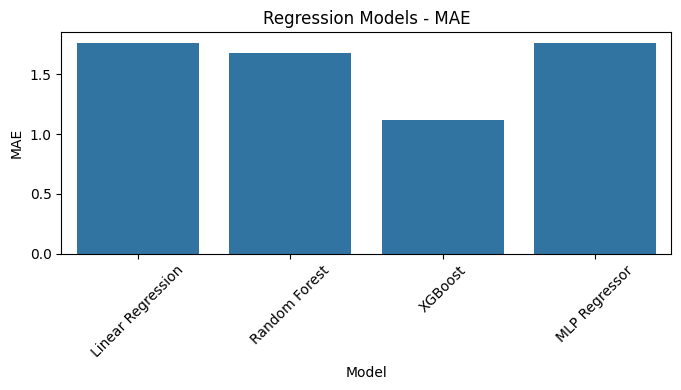

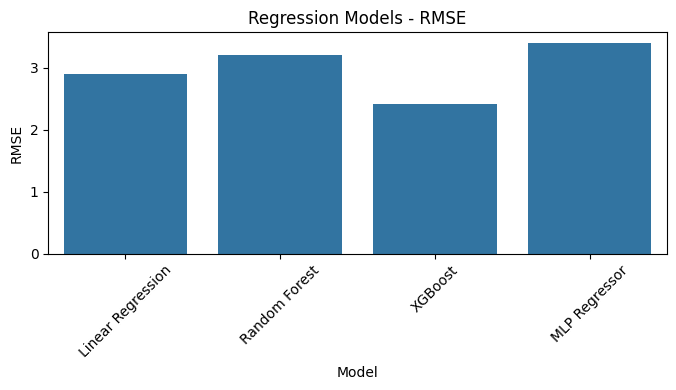

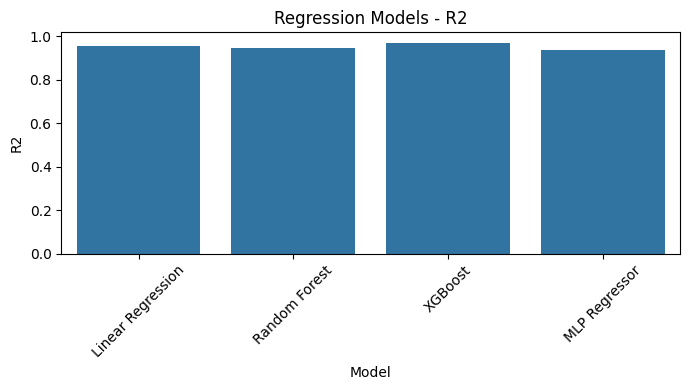

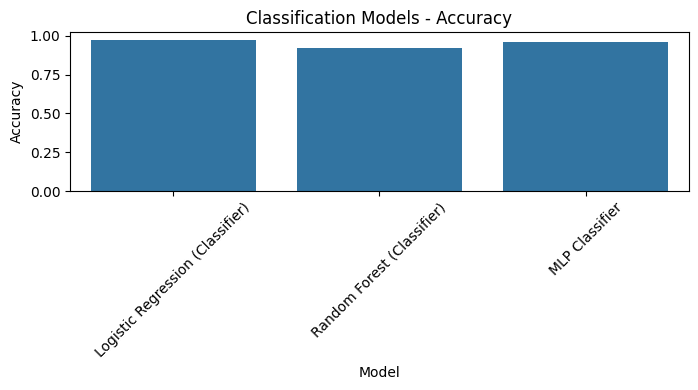

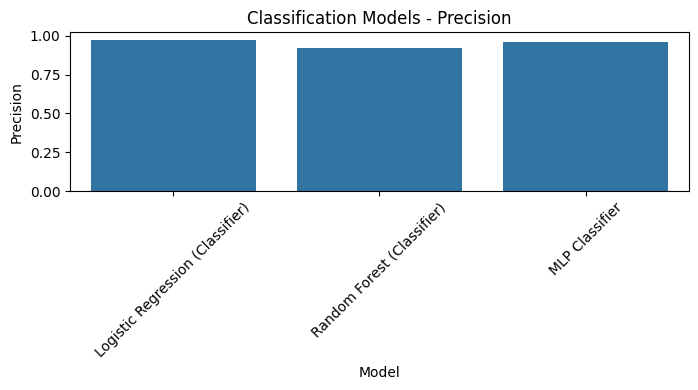

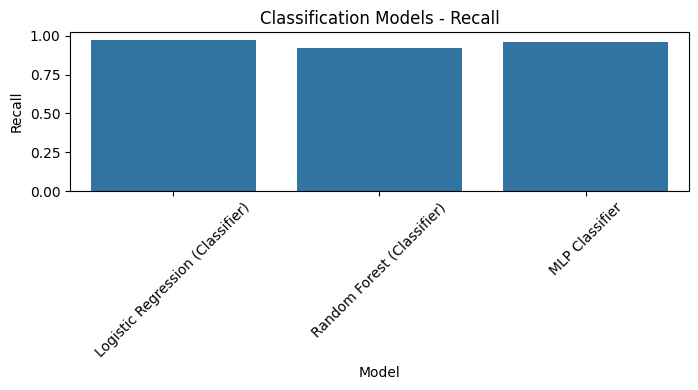

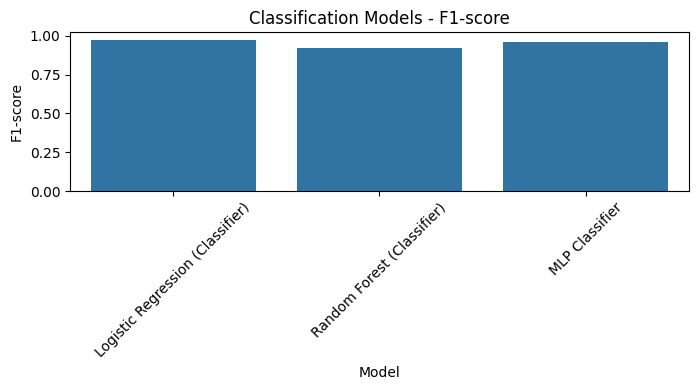

In [5]:
# --- Vizualizacija rezultata ---
from src.visualizations import plot_results


print("\n=== VIZUALIZACIJA REZULTATA ===")
plot_results("../src/results.json")

In [6]:
# --- Zaključak ---
# - Najbolji regresioni model: XGBoost Regressor (R² ≈ 0.993)
# - Najbolji klasifikacioni model: MLP Classifier (Accuracy ≈ 0.975)
# - Projekat omogućava real-time predikciju putem API-ja (CLI i REST modova).
#
# Ovo predstavlja kompletan ML tok projekta: učitavanje → analiza → treniranje → evaluacija → serving.